# 🌎 Expanding to Global Coverage

## Added Market

- South Korea — KOSPI

## Adding Global Benchmarks

We include a global ETF proxy for world equity performance:

- VT (Vanguard Total World Stock ETF)
- URTH (iShares MSCI World ETF)

## Objective

1. Measure world equity performance
2. Rank country indices
3. Identify top 3 performers over chosen period

In [37]:
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# ---------- Indices with flags ----------
indices = {
    "^KS11": "KOSPI (S. Korea) 🇰🇷",
    "^IBEX": "IBEX (Spain) 🇪🇸",
    "^HSI": "HangSeng (HK) 🇭🇰",
    "^FTSE": "FTSE100 (UK) 🇬🇧",
    "^STI": "STI (Singapore) 🇸🇬",
    "000001.SS": "Shanghai (China) 🇨🇳",
    "^GDAXI": "DAX (Germany) 🇩🇪",
    "^IXIC": "NASDAQ (US) 🇺🇸",
    "^GSPC": "S&P500 (US) 🇺🇸",
    "^FCHI": "CAC40 (France) 🇫🇷",
    "^AEX": "AEX (Netherlands) 🇳🇱",
    "^AXJO": "ASX200 (Australia) 🇦🇺",
    "^N225": "Nikkei225 (Japan) 🇯🇵",
    "^SSMI": "SMI (Switzerland) 🇨🇭"
}

# ---------- Download data ----------
daily_prices = {}
returns = {}
for ticker, name in indices.items():
    try:
        df = yf.download(ticker, start="2025-01-01", auto_adjust=True, progress=False)
        if 'Close' in df:
            close = df['Close'].dropna()
            if not close.empty:
                daily_prices[name] = close
                # Compute total return as scalar to avoid FutureWarning
                total_ret = ((close.iloc[-1] / close.iloc[0] - 1) * 100).item()
                returns[name] = total_ret
    except Exception as e:
        print(f"Failed download: {ticker}, {e}")

# ---------- Total Returns Bar Chart ----------
returns_df = pd.DataFrame.from_dict(returns, orient='index', columns=['Total Return']).sort_values('Total Return', ascending=False)
colors = ['green' if x>0 else 'red' if x<0 else 'gray' for x in returns_df['Total Return']]

fig = go.Figure(go.Bar(
    x=returns_df.index,
    y=returns_df['Total Return'],
    text=[f"{v:.1f}%" for v in returns_df['Total Return']],
    textposition='auto',
    marker_color=colors
))
fig.update_layout(
    title={'text':'Total Returns of Major Indices Since Jan 1st 2025','x':0.5,'font':{'size':24}},
    xaxis_title='Index',
    yaxis_title='Total Return (%)',
    xaxis_tickangle=-45,
    height=600,
    template='plotly_white'
)
fig.show()

## 📊 Correlation and Covariance of Index Returns

**📌 Covariance** measures how two variables move together.  
- ➕ Positive covariance: indices tend to move in the **same direction**.  
- ➖ Negative covariance: indices tend to move in **opposite directions**.  
- ⚖️ The scale depends on return magnitudes, so it's hard to compare across indices directly.

**🔗 Correlation** standardizes covariance to a range between -1 and 1.  
- 💯 +1 → indices move **perfectly together**.  
- ❌ -1 → indices move **perfectly inversely**.  
- 0 → **no linear relationship** between indices.  
- 🛡️ Useful for **diversification analysis**, helping reduce portfolio risk.

**💡 Why use these matrices?**  
- Identify how indices **move relative to each other**.  
- Guide **asset allocation** and **risk management** decisions.  
- Help spot **opportunities for diversification** 🌍.

In [38]:
import plotly.express as px

# ---------- Correlation & Covariance Matrices ----------
price_df = pd.concat(daily_prices.values(), axis=1)
price_df.columns = daily_prices.keys()

# Compute daily returns without filling missing values
returns_daily = price_df.pct_change(fill_method=None).dropna()

# Correlation matrix
corr_matrix = returns_daily.corr()

# ---------- Correlation Heatmap ----------
fig_corr = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    title="📈 Correlation Heatmap of Major Indices (Daily Returns)",
    aspect="auto"
)
fig_corr.update_layout(height=700, width=900)
fig_corr.show()

In [45]:
import pandas as pd
import plotly.graph_objects as go
import yfinance as yf

# ---------- FX mapping to USD ----------
fx_symbols = {
    "KOSPI (S. Korea) 🇰🇷": "KRWUSD=X",
    "IBEX (Spain) 🇪🇸": "EURUSD=X",
    "HangSeng (HK) 🇭🇰": "HKDUSD=X",
    "FTSE100 (UK) 🇬🇧": "GBPUSD=X",
    "STI (Singapore) 🇸🇬": "SGDUSD=X",
    "Shanghai (China) 🇨🇳": "CNYUSD=X",
    "DAX (Germany) 🇩🇪": "EURUSD=X",
    "NASDAQ (US) 🇺🇸": None,
    "S&P500 (US) 🇺🇸": None,
    "CAC40 (France) 🇫🇷": "EURUSD=X",
    "AEX (Netherlands) 🇳🇱": "EURUSD=X",
    "ASX200 (Australia) 🇦🇺": "AUDUSD=X",
    "Nikkei225 (Japan) 🇯🇵": "JPYUSD=X",
    "SMI (Switzerland) 🇨🇭": "CHFUSD=X"
}

# ---------- Download FX rates ----------
fx_data = {}
for name, fx_symbol in fx_symbols.items():
    if fx_symbol is not None:
        fx = yf.download(fx_symbol, start="2025-01-01", auto_adjust=True, progress=False)['Close'].dropna()
        fx_data[name] = fx[~fx.index.duplicated()]

# ---------- Compute USD-adjusted total returns ----------
usd_returns = {}
for name, prices in daily_prices.items():
    prices_usd = prices.copy()
    
    if name in fx_data:
        # Align FX and prices by index
        df = pd.concat([prices, fx_data[name]], axis=1, join='inner')
        df.columns = ['price', 'fx']
        df['fx'] = df['fx'].ffill().bfill()  # fill any missing FX
        prices_usd = df['price'] * df['fx']

    # Compute total return
    total_return = (prices_usd.iloc[-1] / prices_usd.iloc[0] - 1) * 100
    usd_returns[name] = float(total_return)

# ---------- Plot USD-adjusted returns ----------
usd_returns_df = pd.DataFrame.from_dict(usd_returns, orient='index', columns=['Total Return USD']).sort_values('Total Return USD', ascending=False)
colors = ['green' if x>0 else 'red' if x<0 else 'gray' for x in usd_returns_df['Total Return USD']]

fig = go.Figure(go.Bar(
    x=usd_returns_df.index,
    y=usd_returns_df['Total Return USD'],
    text=[f"{v:.1f}%" for v in usd_returns_df['Total Return USD']],
    textposition='auto',
    marker_color=colors
))

fig.update_layout(
    title={'text':'💵 USD-Adjusted Total Returns of Major Indices Since Jan 1st 2025','x':0.5,'font':{'size':24}},
    xaxis_title='Index',
    yaxis_title='Total Return (%)',
    xaxis_tickangle=-45,
    height=600,
    template='plotly_white'
)

fig.show()

/var/folders/gm/fn54mj5d4b51_7l5j667v4n00000gn/T/ipykernel_6871/460723004.py:44: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



In [63]:
df = gmd()

Downloading: https://www.globalmacrodata.com/GMD_2025_12.csv
Singapore (SGP) data, 2000-2020
21 rows out of 56850 total rows in the dataset
         year ISO3 countryname      nGDP       rGDP       pop  unemp      infl   exports   imports  govdebt_GDP  ltrate
44778  2000.0  SGP   Singapore  165632.4   75574.60  4.027887  2.675  1.348096  311970.1  291535.6       82.256     NaN
44779  2001.0  SGP   Singapore  160885.6   72622.63  4.138012  2.650  1.014695  294250.4  267710.3       94.471     NaN
44780  2002.0  SGP   Singapore  165698.1   77729.44  4.175950  3.550 -0.391705  305027.2  274495.3       96.310     NaN
44781  2003.0  SGP   Singapore  170117.9   83432.41  4.114826  3.950  0.486899  344635.4  297080.9       99.131     NaN
44782  2004.0  SGP   Singapore  194433.0  104836.00  4.166664  3.350  1.673629  415992.7  364701.9       95.691     NaN
44783  2005.0  SGP   Singapore  212723.0  123146.80  4.265762  3.125  0.469848  478966.4  415386.0       92.663     NaN
44784  2006.0  SGP  

In [100]:
import pandas as pd
from global_macro_data import gmd

# =========================================================
# 1️⃣ COUNTRIES
# =========================================================
countries_iso = {
    "USA": "United States 🇺🇸",
    "CHN": "China 🇨🇳",
    "DEU": "Germany 🇩🇪",
    "JPN": "Japan 🇯🇵",
    "KOR": "South Korea 🇰🇷",
    "GBR": "United Kingdom 🇬🇧",
    "FRA": "France 🇫🇷",
    "ESP": "Spain 🇪🇸",
    "NLD": "Netherlands 🇳🇱",
    "AUS": "Australia 🇦🇺",
    "SGP": "Singapore 🇸🇬",
    "CHE": "Switzerland 🇨🇭"
}

# =========================================================
# 2️⃣ DOWNLOAD GDP DATA
# =========================================================
df = gmd(
    country=list(countries_iso.keys()),
    variables=["rGDP_USD"],
    show_preview=False
)

# Map ISO3 to country names
df["Country"] = df["ISO3"].map(countries_iso)

# Keep 2019 onward
df = df[df["year"] >= 2019].copy()

# Ensure numeric
df["rGDP_USD"] = pd.to_numeric(df["rGDP_USD"], errors="coerce")

# =========================================================
# 3️⃣ CREATE GDP TABLE (BILLIONS USD)
# =========================================================
gdp_table = df.pivot(
    index="Country",
    columns="year",
    values="rGDP_USD"
)

# Convert millions → billions
gdp_table_b = (gdp_table / 1e3).round(1)

# =========================================================
# 4️⃣ FIX COLUMN NAMES (YEARS)
# =========================================================
gdp_table_b.columns = gdp_table_b.columns.astype(int)

# =========================================================
# 5️⃣ KEEP ONLY 2019–2025
# =========================================================
years_to_keep = [2019, 2020, 2021, 2022, 2023, 2024, 2025]
gdp_table_b = gdp_table_b[years_to_keep]

# =========================================================
# 6️⃣ RANK BY 2025
# =========================================================
latest_year = 2025
gdp_table_b["Latest GDP"] = gdp_table_b[latest_year]
gdp_table_b = gdp_table_b.sort_values(by="Latest GDP", ascending=False)
gdp_table_b_display = gdp_table_b.drop(columns=["Latest GDP"])

# =========================================================
# 7️⃣ DISPLAY
# =========================================================
print(f"\n📊 Real GDP (Billions USD) — 2019 to {latest_year}, ranked by {latest_year}\n")
display(gdp_table_b_display.style.format("{:,.1f}"))

Downloading: https://www.globalmacrodata.com/GMD_2025_12.csv
Filtered data for countries: USA, CHN, DEU, JPN, KOR, GBR, FRA, ESP, NLD, AUS, SGP, CHE
Selected 4 variables
Final dataset: 5217 observations of 4 variables

📊 Real GDP (Billions USD) — 2019 to 2025, ranked by 2025



year,2019,2020,2021,2022,2023,2024,2025
Country,,,,,,,
United States 🇺🇸,"23,700.0","23,000.0","27,100.0","30,500.0","33,400.0","36,200.0","38,700.0"
China 🇨🇳,"20,300.0","21,300.0","26,200.0","28,300.0","31,100.0","34,100.0","37,500.0"
Japan 🇯🇵,"4,731.6","4,385.9","4,617.4","4,743.5","5,090.2","5,204.6","5,454.4"
Germany 🇩🇪,"4,223.5","3,923.1","4,330.6","4,728.5","5,012.8","5,175.2","5,354.4"
United Kingdom 🇬🇧,"3,681.2","3,109.3","3,668.0","4,251.0","4,592.3","4,808.2","5,075.9"
France 🇫🇷,"2,884.5","2,536.4","2,930.0","3,184.9","3,429.7","3,598.0","3,725.1"
South Korea 🇰🇷,"2,029.4","2,032.8","2,295.5","2,466.2","2,584.1","2,821.8","3,007.5"
Australia 🇦🇺,"1,652.4","1,602.1","1,884.0","2,201.6","2,370.2","2,481.6","2,625.7"
Spain 🇪🇸,"1,536.9","1,232.8","1,439.0","1,698.7","1,902.5","2,077.3","2,216.3"


In [119]:
import pandas as pd
from global_macro_data import gmd

# =========================================================
# 1️⃣ DOWNLOAD rGDP DATA (2025 onward)
# =========================================================
df2 = gmd(
    country=list(countries_iso.keys()),
    variables=["rGDP"],
    show_preview=False
)

# Map ISO3 → country names
df2["Country"] = df2["ISO3"].map(countries_iso)

# Keep 2025 onward
df2 = df2[df2["year"] >= 2025].copy()

# Ensure numeric
df2["rGDP"] = pd.to_numeric(df2["rGDP"], errors="coerce")

# Drop rows without GDP
df2 = df2.dropna(subset=["rGDP"])

# Sort by Country & Year
df2 = df2.sort_values(["Country", "year"])

# =========================================================
# 2️⃣ PIVOT rGDP
# =========================================================
gdp_table = df2.pivot(index="Country", columns="year", values="rGDP")

# =========================================================
# 3️⃣ COMPUTE YoY GROWTH (from 2025)
# =========================================================
gdp_growth = gdp_table.pct_change(axis=1) * 100
gdp_growth = gdp_growth.round(2)

# Drop 2025 column because no previous year to compare
gdp_growth = gdp_growth.drop(columns=[2025])

# Fix column names to integer
gdp_growth.columns = gdp_growth.columns.astype(int)

# =========================================================
# 4️⃣ RANK BY 2026 GROWTH
# =========================================================
gdp_growth = gdp_growth.sort_values(by=2026, ascending=False)

# =========================================================
# 5️⃣ DISPLAY NICE TABLE
# =========================================================
print("📊 Real GDP Growth % — 2026 onward, ranked by 2026 growth\n")
display(
    gdp_growth.style.format("{:,.2f}")
    .set_caption("Real GDP YoY Growth (%) — 2026 to 2029")
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("color", "#000"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "5px")]}
    ])
)

Downloading: https://www.globalmacrodata.com/GMD_2025_12.csv
Filtered data for countries: USA, CHN, DEU, JPN, KOR, GBR, FRA, ESP, NLD, AUS, SGP, CHE
Selected 4 variables
Final dataset: 5217 observations of 4 variables
📊 Real GDP Growth % — 2026 onward, ranked by 2026 growth



year,2026,2027,2028,2029
Country,,,,
China 🇨🇳,10.17,3.85,3.33,3.23
Australia 🇦🇺,7.50,2.20,2.29,2.35
South Korea 🇰🇷,6.45,1.93,2.16,2.12
United States 🇺🇸,6.20,1.95,2.15,2.10
Spain 🇪🇸,6.08,6.17,1.63,1.61
Netherlands 🇳🇱,5.32,5.60,1.51,1.42
Switzerland 🇨🇭,4.85,1.20,1.80,1.20
United Kingdom 🇬🇧,4.61,1.46,1.37,1.35
Germany 🇩🇪,4.14,4.67,0.85,0.74


## Growth rate number wildly exagerrated check other online estimates

In [122]:
# ---------- DOWNLOAD CPI & Inflation (2025 onward) ----------
df = gmd(
    country=list(countries_iso.keys()),
    variables=["CPI", "infl"],
    show_preview=False
)
df["Country"] = df["ISO3"].map(countries_iso)
df = df[df["year"] >= 2025].copy()
df[["CPI","infl"]] = df[["CPI","infl"]].apply(pd.to_numeric, errors="coerce")
df = df.sort_values(["Country","year"])

# ---------- INDEX CPI TO 100 AT 2025 ----------
base_cpi = df[df["year"]==2025].set_index("Country")["CPI"]
df["CPI_Indexed"] = df.apply(lambda r: (r["CPI"]/base_cpi[r["Country"]]*100) if pd.notna(r["CPI"]) else None, axis=1)

# ---------- PIVOT TABLES ----------
cpi_indexed = df.pivot(index="Country", columns="year", values="CPI_Indexed")
infl_table = df.pivot(index="Country", columns="year", values="infl")

# ---------- PLOT CPI LINE CHART ----------
fig_cpi = go.Figure()
for country in cpi_indexed.index:
    fig_cpi.add_trace(go.Scatter(
        x=cpi_indexed.columns.astype(int),
        y=cpi_indexed.loc[country],
        mode="lines+markers",
        name=country
    ))
fig_cpi.update_layout(
    title="📈 CPI Indexed (2025=100) — 2025 onward",
    xaxis_title="Year",
    yaxis_title="CPI (Indexed)",
    template="plotly_white",
    height=500,
    width=1000
)
fig_cpi.show()

# ---------- PLOT INFLATION BAR CHART ----------
fig_infl = go.Figure()
for country in infl_table.index:
    fig_infl.add_trace(go.Bar(
        x=infl_table.columns.astype(int),
        y=infl_table.loc[country],
        name=country
    ))
fig_infl.update_layout(
    barmode='group',
    bargap=0.15,
    bargroupgap=0.05,
    title="📊 Inflation Rate (%) — 2025 onward",
    xaxis_title="Year",
    yaxis_title="Inflation %",
    template="plotly_white",
    height=500,
    width=1000
)
fig_infl.show()

Downloading: https://www.globalmacrodata.com/GMD_2025_12.csv
Filtered data for countries: USA, CHN, DEU, JPN, KOR, GBR, FRA, ESP, NLD, AUS, SGP, CHE
Selected 5 variables
Final dataset: 5217 observations of 5 variables


In [1]:
# Loading libraries
import torch
import datetime
import feedparser
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf

from datetime import datetime, timedelta
from scipy.special import softmax
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification

api_key = "37712ca9cdb6497b9db5171a32fd8496"  # Replace with your actual News API key


In [2]:
# Create a Ticker object for Microsoft and access the news data
msft = yf.Ticker("^GSPC")
news_data = msft.news

# Print the desired information for each article
for article in news_data:
    content = article.get('content')
    if content:
        # Assuming title, publisher, link are now within 'content'
        print("Published Time:", content.get('pubDate'))
        print("Title:", content.get('title'))  
        print("Publisher:", content.get('provider').get('displayName'))  
        print("Link:", content.get('canonicalUrl').get('url'))
        print("Content Type:", content.get('contentType'))
        print("-" * 30)

Published Time: 2026-03-01T13:30:25Z
Title: Here's the great Nvidia stock mystery
Publisher: Yahoo Finance
Link: https://finance.yahoo.com/news/heres-the-great-nvidia-stock-mystery-133025474.html
Content Type: STORY
------------------------------
Published Time: 2026-03-01T17:32:43Z
Title: Dow Jones Futures, Oil Prices Loom; Trump Says Iran's New Leaders 'Want To Talk'
Publisher: Investor's Business Daily
Link: https://www.investors.com/market-trend/stock-market-today/trump-us-israel-massive-attacks-iran-dow-jones-futures-oil-prices/?src=A00220&yptr=yahoo
Content Type: STORY
------------------------------
Published Time: 2026-03-01T15:48:00Z
Title: Iran’s Strait of Hormuz Action Could Lift These Tanker Stocks
Publisher: Barrons.com
Link: https://www.barrons.com/articles/strait-of-hormuz-shipping-stocks-frontline-iran-war-e16c58a1?siteid=yhoof2&yptr=yahoo
Content Type: STORY
------------------------------
Published Time: 2026-03-01T15:22:00Z
Title: Here's the First Energy Stock I Plan t

In [21]:
import feedparser
from urllib.parse import quote
import pandas as pd

# Search query
query = "SP 500"

# URL-encode the query
query_encoded = quote(query)

# Correct RSS URL
rss_url = f"https://news.google.com/rss/search?q={query_encoded}&hl=en-US&gl=US&ceid=US:en"

# Parse feed
feed = feedparser.parse(rss_url)

# Collect entries into a list
results = []
for entry in feed.entries[:20]:  # e.g., first 20 articles
    results.append({
        "Published": entry.get("published"),
        "Title": entry.get("title"),
        "Link": entry.get("link")
    })

# Create DataFrame
news_df = pd.DataFrame(results)

# Display
news_df

,Published,Title,Link
0,"Fri, 27 Feb 2026 21:00:30 GMT","Stock market today: Dow, S&P 500, Nasdaq fall ...",https://news.google.com/rss/articles/CBMi7wFBV...
1,"Sat, 28 Feb 2026 22:15:45 GMT",The Fallout Of U.S.-Iran Round Two (SP500) - S...,https://news.google.com/rss/articles/CBMifkFVX...
2,"Sun, 01 Mar 2026 10:08:31 GMT",Wait for a 10% drop in the S&P 500 before buyi...,https://news.google.com/rss/articles/CBMiwwFBV...
3,"Fri, 27 Feb 2026 19:42:00 GMT",Why the S&P 500 Is Looking ‘Toppy’ - Barron's,https://news.google.com/rss/articles/CBMijgNBV...
4,"Sun, 01 Mar 2026 15:21:00 GMT","Futures, Oil Prices To React To Mideast Fighti...",https://news.google.com/rss/articles/CBMiwgFBV...
5,"Thu, 26 Feb 2026 13:27:52 GMT",The S&P 500 Is Forecast to Rally amid a Health...,https://news.google.com/rss/articles/CBMiqAFBV...
6,"Sun, 01 Mar 2026 13:48:42 GMT",Global Earnings Underscore Shift From US as S&...,https://news.google.com/rss/articles/CBMirwFBV...
7,"Sun, 01 Mar 2026 15:22:45 GMT",S&P 500 (SPX) Opens Up or Down on March 2? Tra...,https://news.google.com/rss/articles/CBMic0FVX...
8,"Sun, 01 Mar 2026 09:12:00 GMT",Buy 2 Vanguard Index Funds to Beat the S&P 500...,https://news.google.com/rss/articles/CBMilgFBV...
9,"Sun, 01 Mar 2026 09:32:00 GMT",Buy 2 Vanguard Index Funds to Beat the S&P 500...,https://news.google.com/rss/articles/CBMitAFBV...


In [22]:
# Save News dataset
news_df.to_csv('news_data.csv', index=False)

## **3.1 Sentiment analysis using FinBERT**

Unfortunately, for us, News API's Sentiment Analysis is a paid feature. If you have access to such a plan, the API response would already include sentiment scores (positive, negative, neutral) for each article. You can then use these scores directly in your trading strategies.

In this lesson, we will use an alternative method by implementing the sensitive scoring function manually. For this, we will use **FinBERT**, a pre-trained NLP model specifically designed for financial text. It's based on the BERT architecture (Bidirectional Encoder Representations from Transformers), a type of Transformer model, and has been fine-tuned on a large corpus of financial data.

**Transformers** are a type of deep learning model that have been very successful in natural language processing (NLP) tasks. They are particularly good at understanding the relationships between different words in a sentence, which is important for tasks like sentiment analysis. FinBERT is a specific type of Transformer model that has been pre-trained on a large corpus of financial text. This means that it has already learned a lot about the language used in financial documents. This makes it particularly good at understanding the nuances of financial language, including jargon, sentiment, and specific financial concepts, and this makes it well suited for tasks like sentiment analysis of financial news articles.

In the following piece of code, we utilize the FinBERT model to apply a sentiment score to each news article. To do this, we first need to preprocess the content of each article using the `preprocess` function. Then, we apply `get_sentiment()` to perform sentiment analysis on a given preprocessed text using the FinBERT model. Here's how it works:

 - **Tokenization:** The preprocessed text is tokenized using the tokenizer object. Tokenization is the process of breaking down the text into individual units (tokens) - words or subwords - that the model can understand. The `return_tensors='pt' ` argument specifies that the tokens should be returned as PyTorch tensors. PyTorch tensors are multi-dimensional arrays that are a fundamental data structure in the PyTorch library. They are similar to NumPy arrays but with some key advantages. As an analogy, think of PyTorch tensors as containers that hold numerical data that can be of various dimensions (e.g., 1D for vectors, 2D for matrices, 3D or higher for more complex data).
 - **Model Inference and Score Extraction using Softmax:** The tokenized input is passed to the FinBERT model for inference. The relevant scores are extracted from the model's output and converted to a NumPy array using `detach().numpy()`. The scores are then passed through the `softmax` function. Softmax converts the scores into probabilities, ensuring that they sum up to 1.

The `get_sentiment()` function returns a dictionary containing the probabilities for negative, neutral, and positive sentiment, with the highest probability first.

The following code snippet processes the response from the News API and performs sentiment analysis (by successive implementation of text preprocessing, tokenization, model inference, and getting a sentiment) on the 'Description' of each retrieved article. We are also dropping rows where 'Description' has been removed and the article is no longer available:


In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from scipy.special import softmax

# Specify the FinBERT model
MODEL = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Text preprocessing
def preprocess(text):
    if text is None:
        return ""
    new_text = []
    for t in text.split():
        t = '' if t.startswith('#') and len(t) > 1 else t
        t = '' if t.startswith('@') and len(t) > 1 else t
        t = '' if t.startswith('http') else t
        if t != '':
            new_text.append(t)
    return " ".join(new_text)

# Sentiment scoring
def get_sentiment(text):
    text = preprocess(text)
    if text.strip() == "":
        return {'positive': 0.0, 'neutral': 1.0, 'negative': 0.0}  # default neutral
    encoded_input = tokenizer(text, return_tensors='pt', truncation=True)
    output = model(**encoded_input)
    scores = softmax(output.logits.detach().numpy()[0])
    # FinBERT labels: positive, neutral, negative
    return {
        'positive': scores[0],
        'neutral': scores[1],
        'negative': scores[2]
    }

# Example usage
example_text = "The stock market is doing really well today!"
print(get_sentiment(example_text))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'positive': np.float32(0.93085724), 'neutral': np.float32(0.017111672), 'negative': np.float32(0.052031115)}


In [23]:
# Open saved DataFrame - OPTIONAL
news_df = pd.read_csv('news_data.csv')
news_df.head()

,Published,Title,Link
0,"Fri, 27 Feb 2026 21:00:30 GMT","Stock market today: Dow, S&P 500, Nasdaq fall ...",https://news.google.com/rss/articles/CBMi7wFBV...
1,"Sat, 28 Feb 2026 22:15:45 GMT",The Fallout Of U.S.-Iran Round Two (SP500) - S...,https://news.google.com/rss/articles/CBMifkFVX...
2,"Sun, 01 Mar 2026 10:08:31 GMT",Wait for a 10% drop in the S&P 500 before buyi...,https://news.google.com/rss/articles/CBMiwwFBV...
3,"Fri, 27 Feb 2026 19:42:00 GMT",Why the S&P 500 Is Looking ‘Toppy’ - Barron's,https://news.google.com/rss/articles/CBMijgNBV...
4,"Sun, 01 Mar 2026 15:21:00 GMT","Futures, Oil Prices To React To Mideast Fighti...",https://news.google.com/rss/articles/CBMiwgFBV...


In [26]:
# Remove any rows with missing titles
news_df = news_df[news_df['Title'].notna()]

# Apply sentiment scoring to the 'Title' column
news_df['Sent_positive'] = news_df['Title'].apply(lambda x: get_sentiment(x)['positive'])
news_df['Sent_negative'] = news_df['Title'].apply(lambda x: get_sentiment(x)['negative'])
news_df['Sent_neutral'] = news_df['Title'].apply(lambda x: get_sentiment(x)['neutral'])

# Display the resulting DataFrame
news_df

,Published,Title,Link,Sent_positive,Sent_negative,Sent_neutral
0,"Fri, 27 Feb 2026 21:00:30 GMT","Stock market today: Dow, S&P 500, Nasdaq fall ...",https://news.google.com/rss/articles/CBMi7wFBV...,0.009494,0.033490,0.957017
1,"Sat, 28 Feb 2026 22:15:45 GMT",The Fallout Of U.S.-Iran Round Two (SP500) - S...,https://news.google.com/rss/articles/CBMifkFVX...,0.093554,0.697185,0.209261
2,"Sun, 01 Mar 2026 10:08:31 GMT",Wait for a 10% drop in the S&P 500 before buyi...,https://news.google.com/rss/articles/CBMiwwFBV...,0.024900,0.293618,0.681482
3,"Fri, 27 Feb 2026 19:42:00 GMT",Why the S&P 500 Is Looking ‘Toppy’ - Barron's,https://news.google.com/rss/articles/CBMijgNBV...,0.045211,0.872434,0.082355
4,"Sun, 01 Mar 2026 15:21:00 GMT","Futures, Oil Prices To React To Mideast Fighti...",https://news.google.com/rss/articles/CBMiwgFBV...,0.033513,0.924222,0.042266
5,"Thu, 26 Feb 2026 13:27:52 GMT",The S&P 500 Is Forecast to Rally amid a Health...,https://news.google.com/rss/articles/CBMiqAFBV...,0.905410,0.076514,0.018076
6,"Sun, 01 Mar 2026 13:48:42 GMT",Global Earnings Underscore Shift From US as S&...,https://news.google.com/rss/articles/CBMirwFBV...,0.068254,0.688624,0.243122
7,"Sun, 01 Mar 2026 15:22:45 GMT",S&P 500 (SPX) Opens Up or Down on March 2? Tra...,https://news.google.com/rss/articles/CBMic0FVX...,0.028509,0.311133,0.660358
8,"Sun, 01 Mar 2026 09:12:00 GMT",Buy 2 Vanguard Index Funds to Beat the S&P 500...,https://news.google.com/rss/articles/CBMilgFBV...,0.737692,0.252728,0.009580
9,"Sun, 01 Mar 2026 09:32:00 GMT",Buy 2 Vanguard Index Funds to Beat the S&P 500...,https://news.google.com/rss/articles/CBMitAFBV...,0.778645,0.212744,0.008611


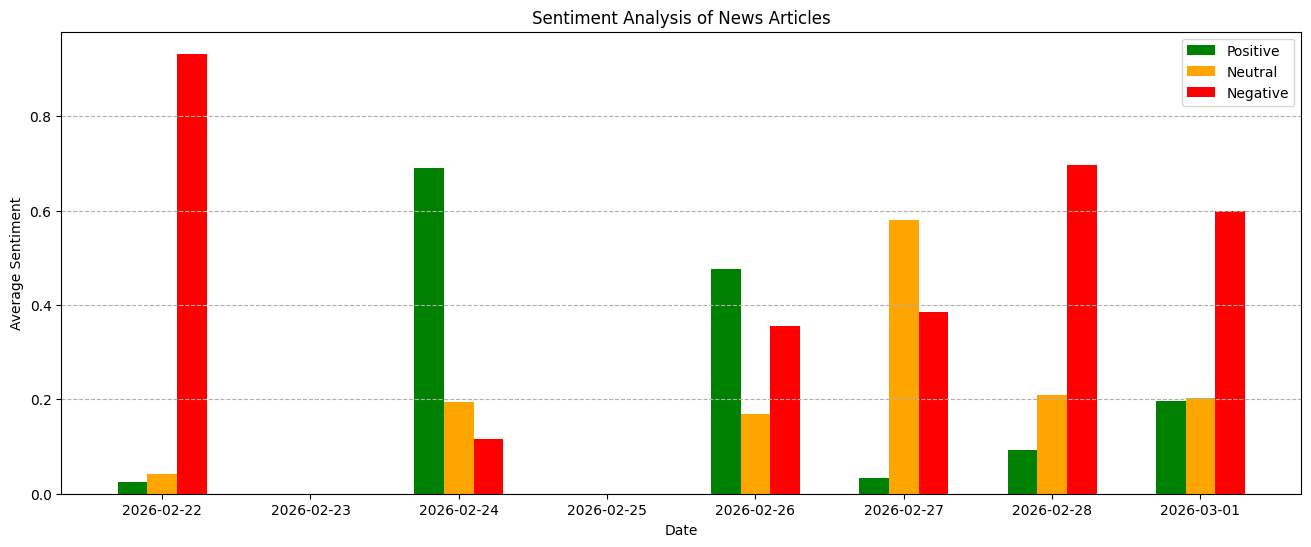

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Published' is datetime
news_df['Published'] = pd.to_datetime(news_df['Published'])

# Extract just the date (drop time)
news_df['Date'] = news_df['Published'].dt.date

# Group by date and calculate average sentiment
Ndf_grouped = news_df.groupby('Date')[['Sent_positive', 'Sent_neutral', 'Sent_negative']].mean()

# Convert index to datetime for plotting
Ndf_grouped.index = pd.to_datetime(Ndf_grouped.index)

# Plot sentiment as side-by-side bars
fig, ax = plt.subplots(figsize=(16, 6))
width = 0.2

ax.bar(Ndf_grouped.index - pd.Timedelta(days=width), Ndf_grouped['Sent_positive'], width=width, label='Positive', color='green')
ax.bar(Ndf_grouped.index, Ndf_grouped['Sent_neutral'], width=width, label='Neutral', color='orange')
ax.bar(Ndf_grouped.index + pd.Timedelta(days=width), Ndf_grouped['Sent_negative'], width=width, label='Negative', color='red')

# Set plot attributes
ax.set_xlabel('Date')
ax.set_ylabel('Average Sentiment')
ax.set_title('Sentiment Analysis of News Articles')
ax.legend()
ax.grid(True, axis='y', linestyle='--')

plt.show()

# Sector Analysis